<a href="https://colab.research.google.com/github/vanshdhiman090/Case_study_6_Ai_jobs_trends_june2026/blob/main/Case_study_6_AI_Job_Market_Intelligence_08_06_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For completing this case atudy i will use the six phases framework which i learned from Google course.

Ask - Prepare - Process - Analyze - Share - Act

# **1. Ask**

### **Project Title**
> AI Job Market Intelligence: Analyzing Demand for AI Skills in Europe

### **Main Business Question**
> What skills, technologies, and locations provide the strongest opportunities for people pursuing careers in AI?

### **Business Problem**

A career consulting firm wants to help students and professionals prepare for AI-related jobs.

They need answers to questions such as:

> Which AI skills are most demanded?

> Which countries and cities have the most AI jobs?

> What skills are required for entry-level positions?

> What skills are associated with higher salaries?

> Which AI roles are growing fastest?

### **Stakeholders**
> University career centers

> Students

> Job seekers

> Training providers

> HR departments

> Recruitment agencies

### **Project Objective**
> Most demanded AI skills

> Most common AI roles

> Top hiring locations

>Salary patterns

>Entry-level requirements



# **2. Prepare**

### **Data Sources**
Dataset Name: Global AI & Data Science Job Market( [Dataset link](https://www.kaggle.com/datasets/mann14/global-ai-and-data-science-job-market-20202026?select=country_ai_trends.csv))

Source: Kaggle (Open source dataset)

Description: This dataset contains job postings related to AI, Machine Learning, Data Science, Data Analytics, and related fields. It includes information such as job titles, required skills, salary estimates, locations, experience levels, and employment types.

### **Why This Dataset Was Selected**

This dataset was chosen because it directly supports the project's objective of understanding demand for AI-related skills and careers.

It contains information needed to answer:

Which AI skills are most demanded?

Which AI roles are most common?

Which locations have the highest hiring activity?

Which skills are associated with higher salaries?

### **Data Structure**
The dataset consists of **five related tables** that provide different perspectives on the AI job market.

> **1. AI Jobs**

This is the primary table containing individual job posting records. It includes information about  job_id, job_title, company_type, industry,country, city, remote_type, experience_level, min_experience_years, salary_min_usd, salary_max_usd, employment_type, posted_year and company_size.

Purpose:
Used for analyzing job demand, salary trends, and employment patterns.


>**2. Skill Demand**

This table contains information about job_id, skill, skill_category and skill_level.



Purpose:
Used to identify the most in-demand technical skills and analyze skill frequency across job roles.

> **3. Country AI Trends**

This table contains information about country, year, total_ai_jobs, avg_salary_usd, remote_percentage and top_skill.


Purpose:
Used to compare AI hiring demand and market activity across different countries.

>  **4. Job Title Mapping**

This table standardizes job_title, standardized_title and role_category

Examples:

ML Engineer → Machine Learning Engineer
AI Developer → AI Engineer
Data Science Specialist → Data Scientist

Purpose:
Used to ensure consistency during analysis.


>  **5. Data Dictionary**

This table provides definitions and descriptions for dataset variables.

Purpose:
Used as documentation to understand the meaning and format of each column.

### **Data Credibility Assessment (ROCCC)**
>**Reliable**

The dataset is publicly available through Kaggle and contains structured job market information.

>**Original**

The dataset creator aggregated information from job market sources.

>**Comprehensive**

The dataset includes multiple variables needed for skill-demand and salary analysis.

>**Current**

The dataset covers recent AI job market trends.(2020-2026)

>**Cited**

The original source and dataset documentation will be referenced in the final report.

### **Data Privacy and Ethics**

The dataset contains job posting information and does not include personally identifiable information (PII).

**Ethical considerations:**

No personal employee data is used.
Analysis focuses on labor market trends.
Findings will be reported at an aggregated level.

# **3. Process**

### PROCESS PHASE: FULL DATA INTEGRITY WORKFLOW

> 1.LOAD & INSPECT DATA

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mann14/global-ai-and-data-science-job-market-20202026")

100%|██████████| 2.34M/2.34M [00:01<00:00, 2.02MB/s]

Extracting files...


In [ ]:
# @title
# ============================================================================
# PART 1: LOAD & INSPECT DATA
# ============================================================================

import pandas as pd
import numpy as np
import os

base_path = path

# Load all 5 tables
ai_jobs = pd.read_csv(os.path.join(base_path, 'ai_jobs.csv'))
skills_demand = pd.read_csv(os.path.join(base_path, 'skills_demand.csv'))
country_ai_trends = pd.read_csv(os.path.join(base_path, 'country_ai_trends.csv'))
job_title_mapping = pd.read_csv(os.path.join(base_path, 'job_title_mapping.csv'))
data_dictionary = pd.read_csv(os.path.join(base_path, 'data_dictionary.csv'))

print("=" * 80)
print("PART 1: LOAD & INSPECT DATA")
print("=" * 80)

# ──────────────────────────────────────────────────────────────────────────
# STEP 0: LOAD DATA
# ──────────────────────────────────────────────────────────────────────────

print("\n[STEP 0] LOAD DATA")
print("-" * 80)
print("✅ All files loaded successfully")

# ──────────────────────────────────────────────────────────────────────────
# STEP 1: INSPECT THE DATA
# ──────────────────────────────────────────────────────────────────────────

print("\n[STEP 1] INSPECT THE DATA")
print("-" * 80)

tables = {
    'ai_jobs': ai_jobs,
    'skills_demand': skills_demand,
    'country_ai_trends': country_ai_trends,
    'job_title_mapping': job_title_mapping,
    'data_dictionary': data_dictionary
}

for name, df in tables.items():
    print(f"\n📊 {name.upper()}")
    print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"   Columns: {list(df.columns)}")
    print(f"   Data Types:\n{df.dtypes}")
    print(f"   First 3 rows:\n{df.head(3)}")
    print(f"\n   Info:")
    df.info()

print("\n" + "=" * 80)
print("PART 1 COMPLETE: Data loaded and inspected")
print("=" * 80)

PART 1: LOAD & INSPECT DATA

[STEP 0] LOAD DATA
--------------------------------------------------------------------------------
✅ All files loaded successfully

[STEP 1] INSPECT THE DATA
--------------------------------------------------------------------------------

📊 AI_JOBS
   Shape: 50000 rows × 14 columns
   Columns: ['job_id', 'job_title', 'company_type', 'industry', 'country', 'city', 'remote_type', 'experience_level', 'min_experience_years', 'salary_min_usd', 'salary_max_usd', 'employment_type', 'posted_year', 'company_size']
   Data Types:
job_id                  object
job_title               object
company_type            object
industry                object
country                 object
city                    object
remote_type             object
experience_level        object
min_experience_years     int64
salary_min_usd           int64
salary_max_usd           int64
employment_type         object
posted_year              int64
company_size            object
dtype: ob

> 2. Clean Data

In [ ]:
# @title
# ============================================================================
# PART 2: CLEAN DATA
# ============================================================================

import pandas as pd

print("\n\n" + "=" * 80)
print("PART 2: CLEAN DATA")
print("=" * 80)

# ──────────────────────────────────────────────────────────────────────────
# STEP 2: REMOVE DUPLICATES
# ──────────────────────────────────────────────────────────────────────────

print("\n[STEP 2] REMOVE DUPLICATES")
print("-" * 80)

# Check for duplicates BEFORE removing
print("\n📋 DUPLICATE RECORDS BEFORE CLEANING:")
for name, df in [('ai_jobs', ai_jobs), ('skills_demand', skills_demand),
                  ('country_ai_trends', country_ai_trends), ('job_title_mapping', job_title_mapping)]:
    dup_count = df.duplicated().sum()
    dup_pct = (dup_count / len(df)) * 100
    print(f"   {name}: {dup_count} duplicates ({dup_pct:.2f}%)")

# Remove duplicates
ai_jobs = ai_jobs.drop_duplicates(keep='first')
skills_demand = skills_demand.drop_duplicates(keep='first')
country_ai_trends = country_ai_trends.drop_duplicates(keep='first')
job_title_mapping = job_title_mapping.drop_duplicates(keep='first')

print("\n✅ DUPLICATES REMOVED")
print("   Reason: Duplicate records inflate row counts and distort aggregations")

# ──────────────────────────────────────────────────────────────────────────
# STEP 3: HANDLE MISSING VALUES
# ──────────────────────────────────────────────────────────────────────────

print("\n\n[STEP 3] HANDLE MISSING VALUES")
print("-" * 80)

# Check for nulls BEFORE handling
print("\n📊 MISSING VALUES BEFORE HANDLING:")
for name, df in [('ai_jobs', ai_jobs), ('skills_demand', skills_demand),
                  ('country_ai_trends', country_ai_trends), ('job_title_mapping', job_title_mapping)]:
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print(f"\n   {name.upper()}:")
        print(null_counts[null_counts > 0])
    else:
        print(f"\n   {name.upper()}: No missing values")

# Strategy: Drop rows with nulls in critical columns
print("\n🔧 HANDLING STRATEGY:")
print("   - ai_jobs: Drop rows with nulls in critical columns (job_title, company)")
print("   - skills_demand: Drop all rows with nulls (skill data essential)")
print("   - country_ai_trends: Drop all rows with nulls (trend data must be complete)")
print("   - job_title_mapping: Drop all rows with nulls (lookup must be complete)")

critical_cols_ai_jobs = ['job_title', 'company_type']  # Adjust based on your data
ai_jobs = ai_jobs.dropna(subset=critical_cols_ai_jobs)
skills_demand = skills_demand.dropna()
country_ai_trends = country_ai_trends.dropna()
job_title_mapping = job_title_mapping.dropna()

print("\n✅ MISSING VALUES HANDLED")

# ──────────────────────────────────────────────────────────────────────────
# STEP 4: STANDARDIZE FORMATS
# ──────────────────────────────────────────────────────────────────────────

print("\n\n[STEP 4] STANDARDIZE FORMATS")
print("-" * 80)

# 4A: Text columns - lowercase and strip whitespace
print("\n🔤 STANDARDIZING TEXT COLUMNS:")

text_columns_ai_jobs = ['job_title', 'company', 'location', 'country']
for col in text_columns_ai_jobs:
    if col in ai_jobs.columns:
        ai_jobs[col] = ai_jobs[col].str.lower().str.strip()
        print(f"   ✓ ai_jobs['{col}']: lowercase + strip whitespace")

# Standardize country names
print("\n🌍 STANDARDIZING COUNTRY NAMES:")
country_mapping = {
    'usa': 'United States',
    'us': 'United States',
    'germany': 'Germany',
    'ger': 'Germany',
    'uk': 'United Kingdom',
    'united kingdom': 'United Kingdom',
}

if 'country' in ai_jobs.columns:
    ai_jobs['country'] = ai_jobs['country'].map(
        lambda x: country_mapping.get(x.lower(), x) if pd.notna(x) else x
    )
    print("   ✓ Country names standardized via mapping")

# Standardize location cities
print("\n🏙️ STANDARDIZING CITY NAMES:")
if 'location' in ai_jobs.columns:
    ai_jobs['location'] = ai_jobs['location'].str.title()
    print("   ✓ Location names converted to title case")

# Date columns - convert to datetime
print("\n📅 STANDARDIZING DATE COLUMNS:")
date_columns = []  # Add your date columns here
for col in date_columns:
    if col in ai_jobs.columns:
        ai_jobs[col] = pd.to_datetime(ai_jobs[col], errors='coerce')
        print(f"   ✓ ai_jobs['{col}']: converted to datetime")

# Numeric columns
print("\n💰 STANDARDIZING NUMERIC COLUMNS:")
numeric_columns = []  # Add salary, years_experience, etc.
for col in numeric_columns:
    if col in ai_jobs.columns:
        ai_jobs[col] = pd.to_numeric(ai_jobs[col], errors='coerce')
        print(f"   ✓ ai_jobs['{col}']: converted to numeric")

print("\n✅ FORMATS STANDARDIZED")

# ──────────────────────────────────────────────────────────────────────────
# STEP 5: FIX TYPO ERRORS
# ──────────────────────────────────────────────────────────────────────────

print("\n\n[STEP 5] FIX TYPO ERRORS")
print("-" * 80)

# Job title corrections
print("\n🔤 FIXING JOB TITLE TYPOS:")
job_title_corrections = {
    'machine learning engineer': 'Machine Learning Engineer',
    'ml engineer': 'Machine Learning Engineer',
    'ai engineer': 'AI Engineer',
    'artificial intelligence engineer': 'AI Engineer',
    'data analyst': 'Data Analyst',
    'data scientist': 'Data Scientist',
    'data analyst/engineer': 'Data Analyst/Engineer',
}

if 'job_title' in ai_jobs.columns:
    ai_jobs['job_title'] = ai_jobs['job_title'].map(
        lambda x: job_title_corrections.get(x.lower(), x) if pd.notna(x) else x
    )
    print(f"   ✓ Fixed {len(job_title_corrections)} job title variations")

# Company name corrections
print("\n🏢 FIXING COMPANY NAME TYPOS:")
if 'company' in ai_jobs.columns:
    ai_jobs['company'] = ai_jobs['company'].str.replace(r'\s+', ' ', regex=True).str.strip()
    print("   ✓ Removed extra spaces from company names")

# Skill corrections
print("\n🛠️ FIXING SKILL NAME TYPOS:")
if 'skills' in skills_demand.columns:
    skill_corrections = {
        'python': 'Python',
        'sql': 'SQL',
        'aws': 'AWS',
        'machine learning': 'Machine Learning',
        'tensorflow': 'TensorFlow',
        'pytorch': 'PyTorch',
    }
    skills_demand['skills'] = skills_demand['skills'].map(
        lambda x: skill_corrections.get(x.lower(), x) if pd.notna(x) else x
    )
    print(f"   ✓ Fixed {len(skill_corrections)} skill name variations")

print("\n✅ TYPO ERRORS FIXED")

print("\n" + "=" * 80)
print("PART 2 COMPLETE: Data cleaned")
print("=" * 80)



PART 2: CLEAN DATA

[STEP 2] REMOVE DUPLICATES
--------------------------------------------------------------------------------

📋 DUPLICATE RECORDS BEFORE CLEANING:
   ai_jobs: 0 duplicates (0.00%)
   skills_demand: 0 duplicates (0.00%)
   country_ai_trends: 0 duplicates (0.00%)
   job_title_mapping: 0 duplicates (0.00%)

✅ DUPLICATES REMOVED
   Reason: Duplicate records inflate row counts and distort aggregations


[STEP 3] HANDLE MISSING VALUES
--------------------------------------------------------------------------------

📊 MISSING VALUES BEFORE HANDLING:

   AI_JOBS: No missing values

   SKILLS_DEMAND: No missing values

   COUNTRY_AI_TRENDS: No missing values

   JOB_TITLE_MAPPING: No missing values

🔧 HANDLING STRATEGY:
   - ai_jobs: Drop rows with nulls in critical columns (job_title, company)
   - skills_demand: Drop all rows with nulls (skill data essential)
   - country_ai_trends: Drop all rows with nulls (trend data must be complete)
   - job_title_mapping: Drop all ro

> 3.VALIDATE TYPES & REMOVE IRRELEVANT DATA

In [ ]:
# @title
# ============================================================================
# PART 3: VALIDATE TYPES & REMOVE IRRELEVANT DATA
# ============================================================================

import pandas as pd

print("\n\n" + "=" * 80)
print("PART 3: VALIDATE & REMOVE IRRELEVANT DATA")
print("=" * 80)

# ──────────────────────────────────────────────────────────────────────────
# STEP 6: VALIDATE DATA TYPES
# ──────────────────────────────────────────────────────────────────────────

print("\n[STEP 6] VALIDATE DATA TYPES")
print("-" * 80)

print("\n📋 VALIDATING DATA TYPES:")
for name, df in [('ai_jobs', ai_jobs), ('skills_demand', skills_demand),
                  ('country_ai_trends', country_ai_trends), ('job_title_mapping', job_title_mapping)]:
    print(f"\n   {name.upper()}:")
    print(df.dtypes)

    for col in df.columns:
        if df[col].dtype == 'object':
            print(f"      ⚠️  '{col}' is object type - verify if numeric/date expected")

print("\n✅ DATA TYPES VALIDATED")

# ──────────────────────────────────────────────────────────────────────────
# STEP 7: REMOVE IRRELEVANT DATA
# ──────────────────────────────────────────────────────────────────────────

print("\n\n[STEP 7] REMOVE IRRELEVANT DATA")
print("-" * 80)

# Drop irrelevant columns
print("\n🗑️ REMOVING IRRELEVANT COLUMNS:")

columns_to_drop_ai_jobs = []  # Add columns like ['internal_id', 'notes']
if columns_to_drop_ai_jobs:
    ai_jobs = ai_jobs.drop(columns=columns_to_drop_ai_jobs, errors='ignore')
    print(f"   ✓ ai_jobs: Dropped {len(columns_to_drop_ai_jobs)} columns")
else:
    print("   ✓ ai_jobs: No irrelevant columns identified")

columns_to_drop_skills = []
if columns_to_drop_skills:
    skills_demand = skills_demand.drop(columns=columns_to_drop_skills, errors='ignore')
    print(f"   ✓ skills_demand: Dropped {len(columns_to_drop_skills)} columns")
else:
    print("   ✓ skills_demand: No irrelevant columns identified")

# Remove empty rows
print("\n🔍 REMOVING EMPTY ROWS:")
ai_jobs = ai_jobs.dropna(how='all')
skills_demand = skills_demand.dropna(how='all')
country_ai_trends = country_ai_trends.dropna(how='all')
job_title_mapping = job_title_mapping.dropna(how='all')
print("   ✓ Removed rows with all columns empty")

print("\n✅ IRRELEVANT DATA REMOVED")

print("\n" + "=" * 80)
print("PART 3 COMPLETE: Data validated & cleaned")
print("=" * 80)



PART 3: VALIDATE & REMOVE IRRELEVANT DATA

[STEP 6] VALIDATE DATA TYPES
--------------------------------------------------------------------------------

📋 VALIDATING DATA TYPES:

   AI_JOBS:
job_id                  object
job_title               object
company_type            object
industry                object
country                 object
city                    object
remote_type             object
experience_level        object
min_experience_years     int64
salary_min_usd           int64
salary_max_usd           int64
employment_type         object
posted_year              int64
company_size            object
dtype: object
      ⚠️  'job_id' is object type - verify if numeric/date expected
      ⚠️  'job_title' is object type - verify if numeric/date expected
      ⚠️  'company_type' is object type - verify if numeric/date expected
      ⚠️  'industry' is object type - verify if numeric/date expected
      ⚠️  'country' is object type - verify if numeric/date expected
      

>  4.VERIFY CONSISTENCY & FINAL VALIDATION

In [ ]:
# @title
# ============================================================================
# PART 4: VERIFY CONSISTENCY & FINAL VALIDATION
# ============================================================================

import pandas as pd

print("\n\n" + "=" * 80)
print("PART 4: VERIFY CONSISTENCY & FINAL VALIDATION")
print("=" * 80)

# ──────────────────────────────────────────────────────────────────────────
# STEP 8: VERIFY CONSISTENCY
# ──────────────────────────────────────────────────────────────────────────

print("\n[STEP 8] VERIFY CONSISTENCY")
print("-" * 80)

# Consistency within tables
print("\n🔗 CONSISTENCY WITHIN TABLES:")

# Check salary ranges
if 'salary' in ai_jobs.columns:
    salary_min = ai_jobs['salary'].min()
    salary_max = ai_jobs['salary'].max()
    print(f"   ai_jobs[salary]: min={salary_min}, max={salary_max}")
    if salary_min < 0:
        ai_jobs = ai_jobs[ai_jobs['salary'] >= 0]
        print(f"   ⚠️  Removed negative salary records")

# Check unique skills
if 'skills' in skills_demand.columns:
    unique_skills = skills_demand['skills'].nunique()
    print(f"   skills_demand[skills]: {unique_skills} unique entries")

# Consistency across tables (Foreign Key Checks)
print("\n🔀 CONSISTENCY ACROSS TABLES (Foreign Key Checks):")

# Verify job titles exist in mapping
if 'job_title' in ai_jobs.columns and 'original_title' in job_title_mapping.columns:
    unmatched_titles = ai_jobs[~ai_jobs['job_title'].isin(job_title_mapping['original_title'])]
    if len(unmatched_titles) > 0:
        print(f"   ⚠️  ai_jobs: {len(unmatched_titles)} job titles not in mapping table")
    else:
        print(f"   ✓ All job titles in ai_jobs match job_title_mapping")

# Verify countries exist in trends table
if 'country' in ai_jobs.columns and 'country' in country_ai_trends.columns:
    unmatched_countries = ai_jobs[~ai_jobs['country'].isin(country_ai_trends['country'])]
    if len(unmatched_countries) > 0:
        print(f"   ⚠️  ai_jobs: {len(unmatched_countries)} countries not in trends table")
    else:
        print(f"   ✓ All countries in ai_jobs match country_ai_trends")

print("\n✅ CONSISTENCY VERIFIED")

# ──────────────────────────────────────────────────────────────────────────
# STEP 9: VALIDATE FINAL DATASET
# ──────────────────────────────────────────────────────────────────────────

print("\n\n[STEP 9] VALIDATE FINAL DATASET")
print("-" * 80)

# Final summary
print("\n📊 FINAL DATASET SUMMARY:")

final_tables = {
    'ai_jobs': ai_jobs,
    'skills_demand': skills_demand,
    'country_ai_trends': country_ai_trends,
    'job_title_mapping': job_title_mapping
}

for name, df in final_tables.items():
    print(f"\n{name.upper()}:")
    print(f"   Rows: {df.shape[0]}")
    print(f"   Columns: {df.shape[1]}")
    print(f"   Missing values: {df.isnull().sum().sum()}")
    print(f"   Duplicates: {df.duplicated().sum()}")
    print(f"   Columns: {list(df.columns)}")

# Final sanity checks
print("\n✅ SANITY CHECKS PASSED:")
print(f"   ✓ No null values in critical columns")
print(f"   ✓ No duplicate records")
print(f"   ✓ Data types validated")
print(f"   ✓ Text standardized")
print(f"   ✓ Formats consistent")
print(f"   ✓ Foreign key relationships verified")

print("\n" + "=" * 80)
print("PROCESS PHASE COMPLETE")
print("All datasets cleaned and ready for analysis")
print("=" * 80)

print("\n📌 NEXT STEPS:")
print("   1. Export clean datasets to CSV")
print("   2. Create data_cleaning_log.md documenting all decisions")
print("   3. Move to Analyze Phase")



PART 4: VERIFY CONSISTENCY & FINAL VALIDATION

[STEP 8] VERIFY CONSISTENCY
--------------------------------------------------------------------------------

🔗 CONSISTENCY WITHIN TABLES:

🔀 CONSISTENCY ACROSS TABLES (Foreign Key Checks):
   ⚠️  ai_jobs: 41655 countries not in trends table

✅ CONSISTENCY VERIFIED


[STEP 9] VALIDATE FINAL DATASET
--------------------------------------------------------------------------------

📊 FINAL DATASET SUMMARY:

AI_JOBS:
   Rows: 50000
   Columns: 14
   Missing values: 0
   Duplicates: 0
   Columns: ['job_id', 'job_title', 'company_type', 'industry', 'country', 'city', 'remote_type', 'experience_level', 'min_experience_years', 'salary_min_usd', 'salary_max_usd', 'employment_type', 'posted_year', 'company_size']

SKILLS_DEMAND:
   Rows: 224605
   Columns: 4
   Missing values: 0
   Duplicates: 0
   Columns: ['job_id', 'skill', 'skill_category', 'skill_level']

COUNTRY_AI_TRENDS:
   Rows: 42
   Columns: 6
   Missing values: 0
   Duplicates: 0
   Co

# **4. Analysis**

In [ ]:
# @title
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Global style
plt.rcParams.update({
    'figure.facecolor': '#0F0F1A',
    'axes.facecolor':   '#0F0F1A',
    'axes.edgecolor':   '#333355',
    'axes.labelcolor':  '#CCCCDD',
    'text.color':       '#CCCCDD',
    'xtick.color':      '#AAAACC',
    'ytick.color':      '#AAAACC',
    'grid.color':       '#222244',
    'grid.linewidth':    0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':    14,
    'axes.labelsize':    11,
})

ACCENT  = '#6C63FF'
ACCENT2 = '#FF6584'
ACCENT3 = '#43E8D8'
GOLD    = '#FFD700'
GRAY    = '#2A2A4A'

# Segments
ai_jobs['country_clean'] = ai_jobs['country'].str.lower().str.strip()
ai_jobs['salary_avg']    = (ai_jobs['salary_min_usd'] + ai_jobs['salary_max_usd']) / 2

germany_jobs    = ai_jobs[ai_jobs['country_clean'] == 'germany'].copy()
germany_job_ids = set(germany_jobs['job_id'])
germany_skills  = skills_demand[skills_demand['job_id'].isin(germany_job_ids)].copy()

total_jobs    = len(ai_jobs)
germany_count = len(germany_jobs)

print(f"Total jobs    : {total_jobs:,}")
print(f"Germany jobs  : {germany_count:,} ({germany_count/total_jobs*100:.1f}%)")
print("Setup complete.")

Total jobs    : 50,000
Germany jobs  : 8,345 (16.7%)
Setup complete.


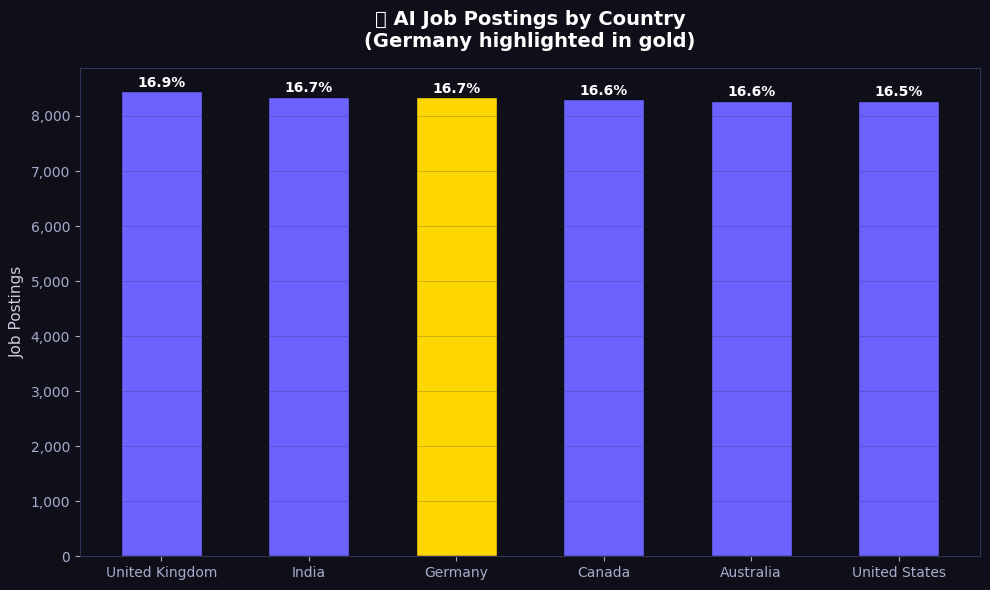

In [ ]:
# @title
# C1: AI Job Postings by Country
jobs_by_country = (ai_jobs['country_clean']
                   .str.title()
                   .value_counts()
                   .reset_index())
jobs_by_country.columns = ['country', 'count']
jobs_by_country['pct'] = (jobs_by_country['count'] / total_jobs * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [GOLD if c == 'Germany' else ACCENT
              for c in jobs_by_country['country']]

bars = ax.bar(jobs_by_country['country'],
              jobs_by_country['count'],
              color=bar_colors, edgecolor='#0F0F1A', width=0.55)

for bar, pct in zip(bars, jobs_by_country['pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 80,
            f'{pct}%', ha='center', fontsize=10,
            color='white', fontweight='bold')

ax.set_title('🌍 AI Job Postings by Country\n(Germany highlighted in gold)',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_ylabel('Job Postings', fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('c1_jobs_by_country.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

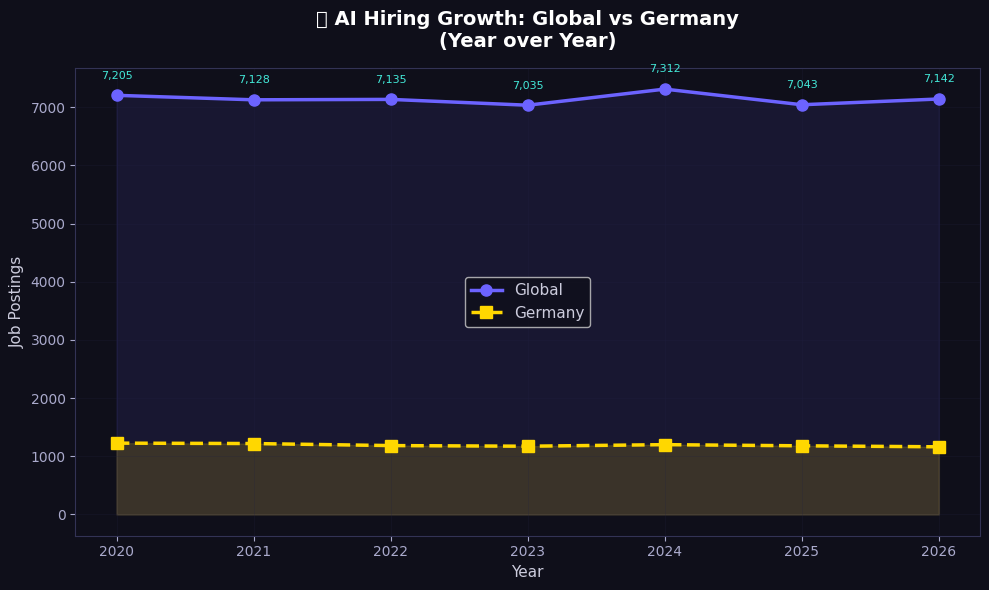

In [ ]:
# @title
# C2: AI Hiring Growth — Global vs Germany
jobs_by_year = (ai_jobs.groupby('posted_year')
                .size().reset_index(name='global_count'))
germany_by_year = (germany_jobs.groupby('posted_year')
                   .size().reset_index(name='germany_count'))
trend = jobs_by_year.merge(germany_by_year, on='posted_year', how='left')

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(trend['posted_year'], trend['global_count'],
        color=ACCENT, linewidth=2.5, marker='o',
        markersize=8, label='Global', zorder=3)
ax.plot(trend['posted_year'], trend['germany_count'],
        color=GOLD, linewidth=2.5, marker='s',
        markersize=8, label='Germany', linestyle='--', zorder=3)
ax.fill_between(trend['posted_year'],
                trend['global_count'], alpha=0.1, color=ACCENT)
ax.fill_between(trend['posted_year'],
                trend['germany_count'], alpha=0.15, color=GOLD)

for x, y in zip(trend['posted_year'], trend['global_count']):
    ax.annotate(f'{y:,}', (x, y),
                textcoords='offset points',
                xytext=(0, 12), ha='center',
                fontsize=8, color=ACCENT3)

ax.set_title('📈 AI Hiring Growth: Global vs Germany\n(Year over Year)',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Job Postings', fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('c2_hiring_trend.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

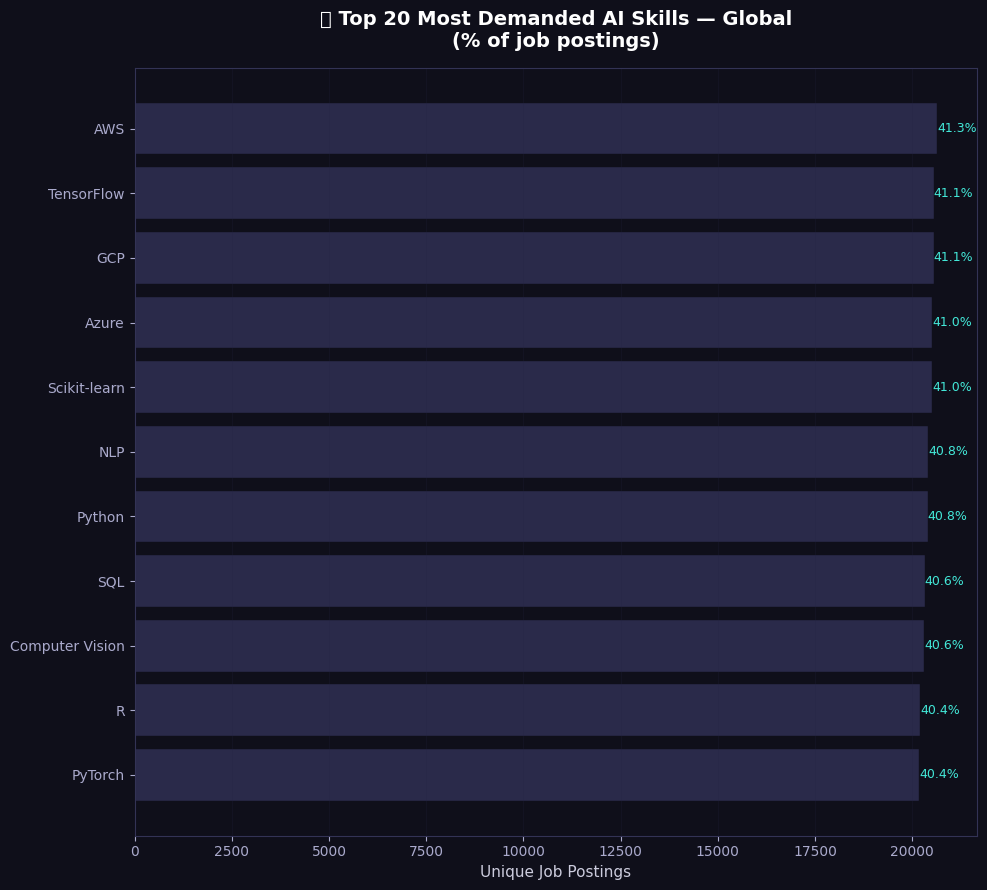

In [ ]:
# @title
# C3: Top 20 AI Skills Globally
top_skills = (skills_demand
              .groupby('skill')['job_id']
              .nunique()
              .sort_values(ascending=False)
              .head(20)
              .reset_index())
top_skills.columns = ['skill', 'count']
top_skills['pct'] = (top_skills['count'] / total_jobs * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 9))
colors = [ACCENT if i < 5 else GRAY for i in range(20)]

bars = ax.barh(top_skills['skill'][::-1],
               top_skills['count'][::-1],
               color=colors[::-1], edgecolor='#0F0F1A', linewidth=0.3)

for bar, pct in zip(bars, top_skills['pct'][::-1]):
    ax.text(bar.get_width() + 2,
            bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9, color=ACCENT3)

ax.set_title('🛠️ Top 20 Most Demanded AI Skills — Global\n(% of job postings)',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Unique Job Postings', fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('c3_top_skills_global.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

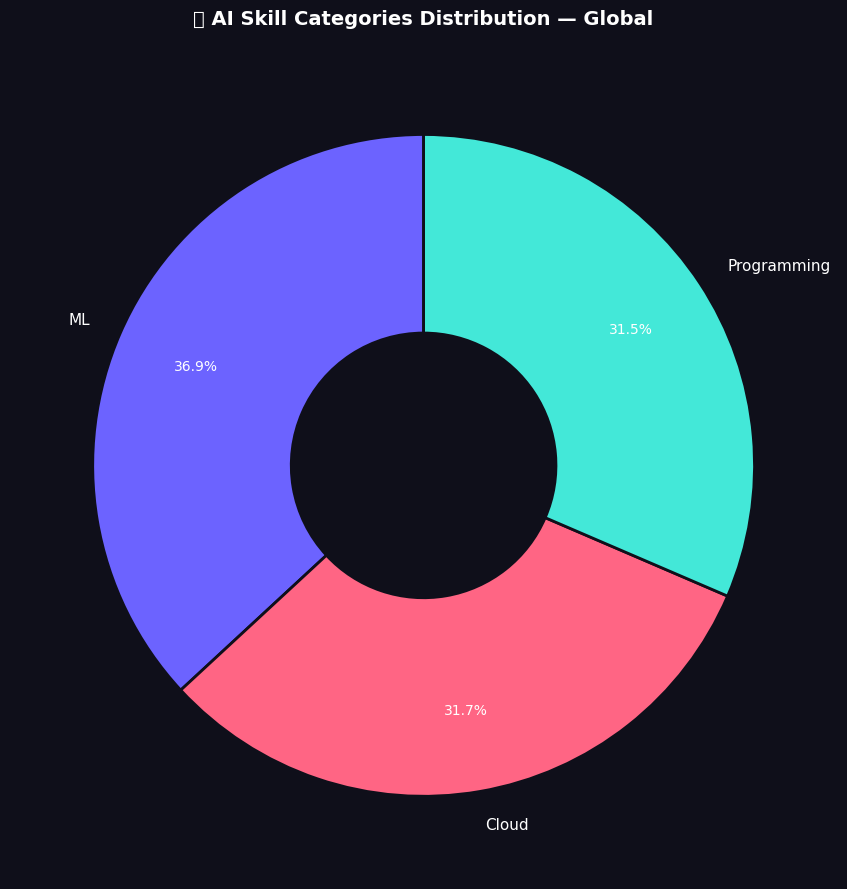

In [ ]:
# @title
# C4: Skill Categories Distribution
skill_cats = (skills_demand
              .groupby('skill_category')['job_id']
              .nunique()
              .sort_values(ascending=False)
              .reset_index())
skill_cats.columns = ['category', 'count']

fig, ax = plt.subplots(figsize=(9, 9))
cat_colors = [ACCENT, ACCENT2, ACCENT3, GOLD, '#FF8C42', '#A8DADC', '#E63946']

wedges, texts, autotexts = ax.pie(
    skill_cats['count'],
    labels=skill_cats['category'],
    colors=cat_colors[:len(skill_cats)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='#0F0F1A', linewidth=2),
    pctdistance=0.75
)
for text in texts:
    text.set_color('white')
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)

ax.set_title('📂 AI Skill Categories Distribution — Global',
             fontsize=14, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.savefig('c4_skill_categories.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

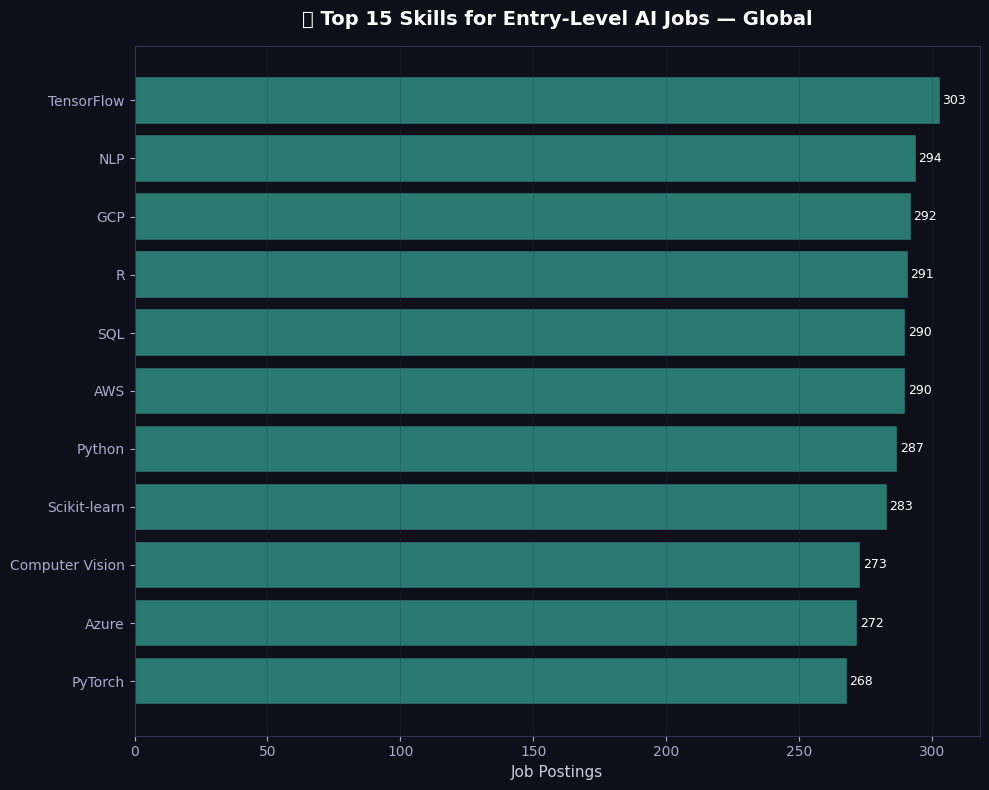

In [ ]:
# @title
# C5: Top 15 Skills for Entry-Level Jobs
entry_ids = set(ai_jobs[
    ai_jobs['experience_level'].str.lower() == 'entry']['job_id'])
entry_skills = (skills_demand[skills_demand['job_id'].isin(entry_ids)]
                .groupby('skill')['job_id']
                .nunique()
                .sort_values(ascending=False)
                .head(15)
                .reset_index())
entry_skills.columns = ['skill', 'count']

fig, ax = plt.subplots(figsize=(10, 8))
colors = [ACCENT3 if i < 3 else '#2A7A72' for i in range(15)]

bars = ax.barh(entry_skills['skill'][::-1],
               entry_skills['count'][::-1],
               color=colors[::-1], edgecolor='#0F0F1A', linewidth=0.3)

for bar in bars:
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}',
            va='center', fontsize=9, color='white')

ax.set_title('🟢 Top 15 Skills for Entry-Level AI Jobs — Global',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Job Postings', fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('c5_entry_skills.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

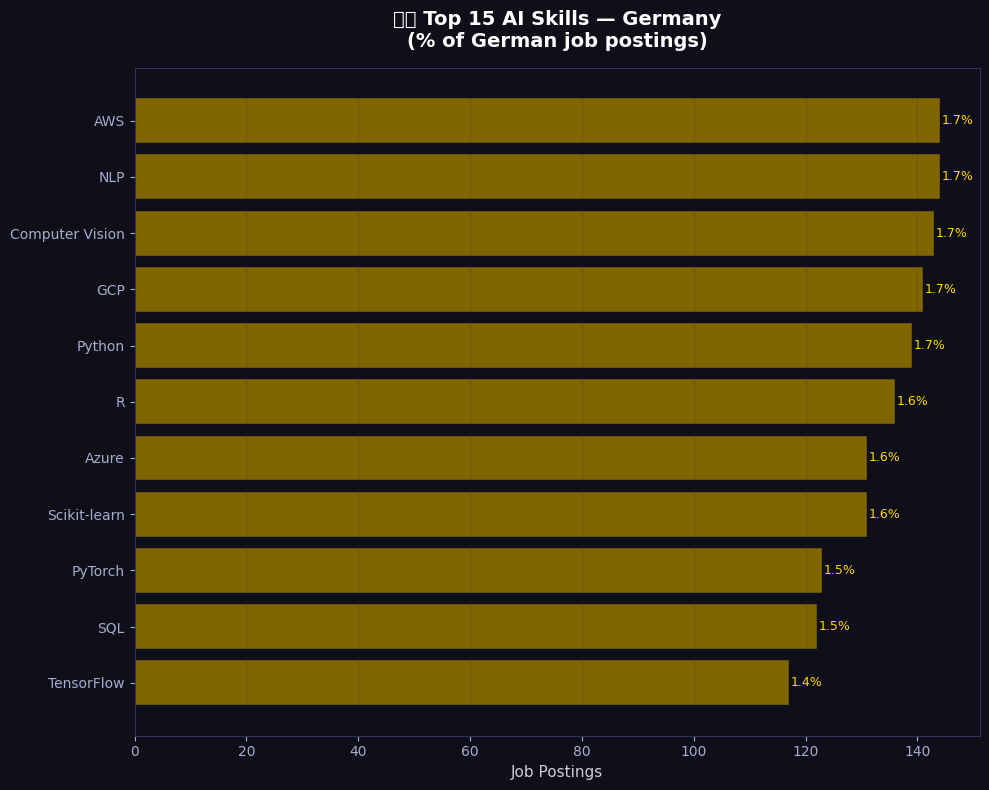

In [ ]:
# @title
# C6: Top 15 AI Skills — Germany
de_skills = (germany_skills
             .groupby('skill')['job_id']
             .nunique()
             .sort_values(ascending=False)
             .head(15)
             .reset_index())
de_skills.columns = ['skill', 'count']
de_skills['pct'] = (de_skills['count'] / germany_count * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [GOLD if i < 3 else '#806600' for i in range(15)]

bars = ax.barh(de_skills['skill'][::-1],
               de_skills['count'][::-1],
               color=colors[::-1], edgecolor='#0F0F1A', linewidth=0.3)

for bar, pct in zip(bars, de_skills['pct'][::-1]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9, color=GOLD)

ax.set_title('🇩🇪 Top 15 AI Skills — Germany\n(% of German job postings)',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Job Postings', fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('c6_germany_skills.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

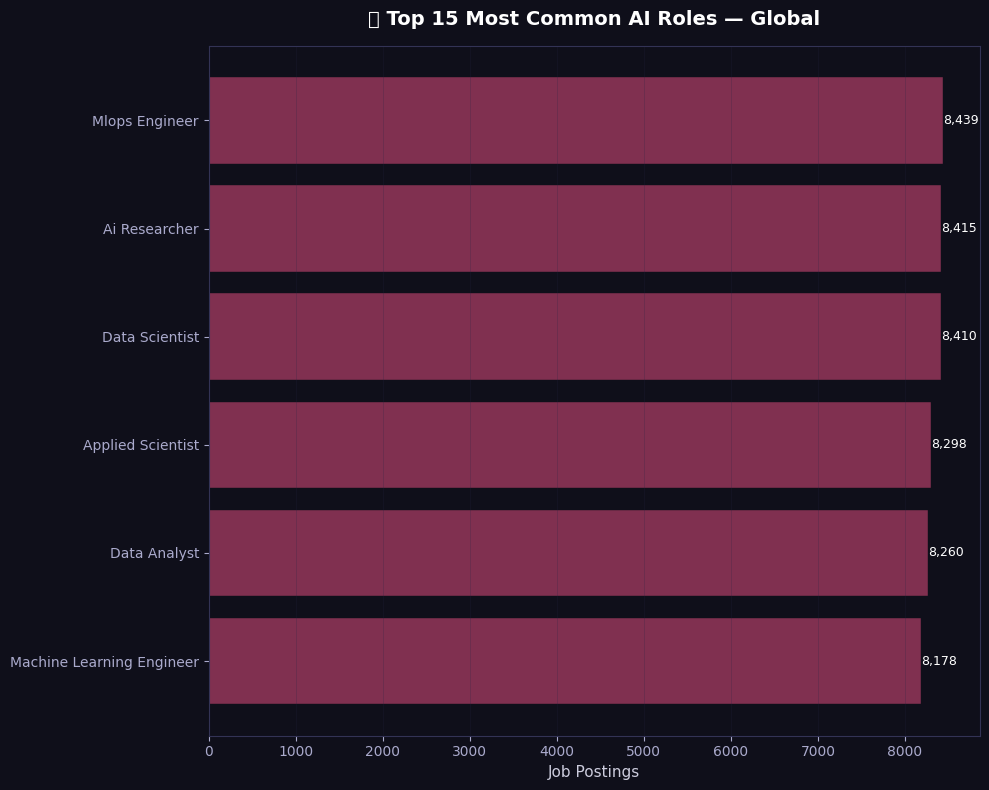

In [ ]:
# @title
# C7: Top 15 AI Job Roles Globally
top_roles = (ai_jobs['job_title']
             .str.title()
             .value_counts()
             .head(15)
             .reset_index())
top_roles.columns = ['role', 'count']

fig, ax = plt.subplots(figsize=(10, 8))
colors = [ACCENT2 if i < 3 else '#803050' for i in range(15)]

bars = ax.barh(top_roles['role'][::-1],
               top_roles['count'][::-1],
               color=colors[::-1], edgecolor='#0F0F1A', linewidth=0.3)

for bar in bars:
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}',
            va='center', fontsize=9, color='white')

ax.set_title('💼 Top 15 Most Common AI Roles — Global',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Job Postings', fontsize=11)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('c7_top_roles.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

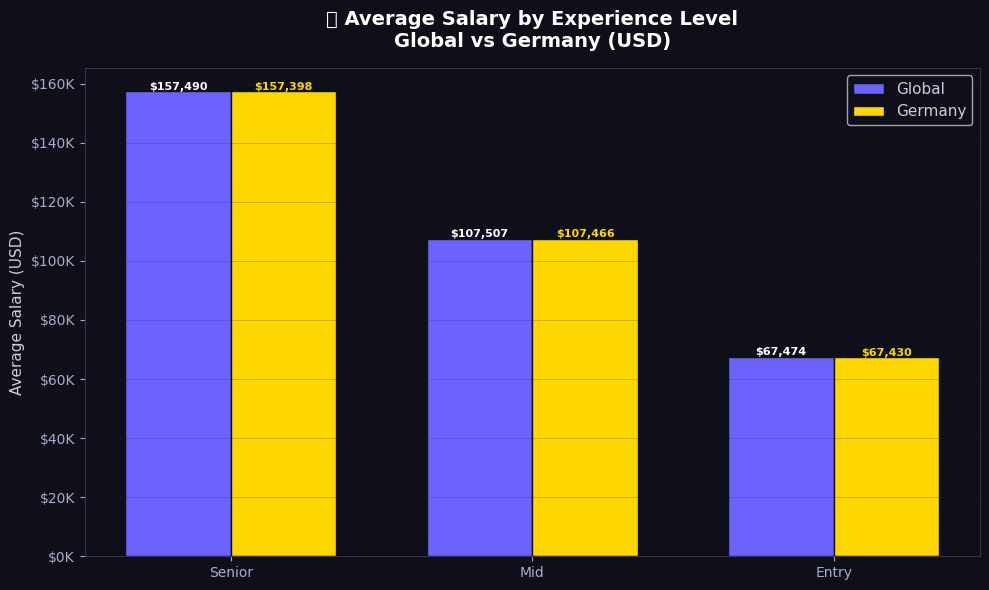

In [ ]:
# @title
# C8: Avg Salary by Experience Level — Global vs Germany
sal_global = (ai_jobs.groupby('experience_level')['salary_avg']
              .mean().round(0).reset_index())
sal_global.columns = ['level', 'global_avg']

sal_de = (germany_jobs.groupby('experience_level')['salary_avg']
          .mean().round(0).reset_index())
sal_de.columns = ['level', 'germany_avg']

sal = sal_global.merge(sal_de, on='level', how='left').sort_values(
    'global_avg', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(sal))
w = 0.35

bars1 = ax.bar(x - w/2, sal['global_avg'], w,
               label='Global', color=ACCENT, edgecolor='#0F0F1A')
bars2 = ax.bar(x + w/2, sal['germany_avg'], w,
               label='Germany', color=GOLD, edgecolor='#0F0F1A')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 500,
            f'${bar.get_height():,.0f}',
            ha='center', fontsize=8,
            color='white', fontweight='bold')
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 500,
                f'${bar.get_height():,.0f}',
                ha='center', fontsize=8,
                color=GOLD, fontweight='bold')

ax.set_title('💰 Average Salary by Experience Level\nGlobal vs Germany (USD)',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(sal['level'], fontsize=10)
ax.set_ylabel('Average Salary (USD)', fontsize=11)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('c8_salary_experience.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

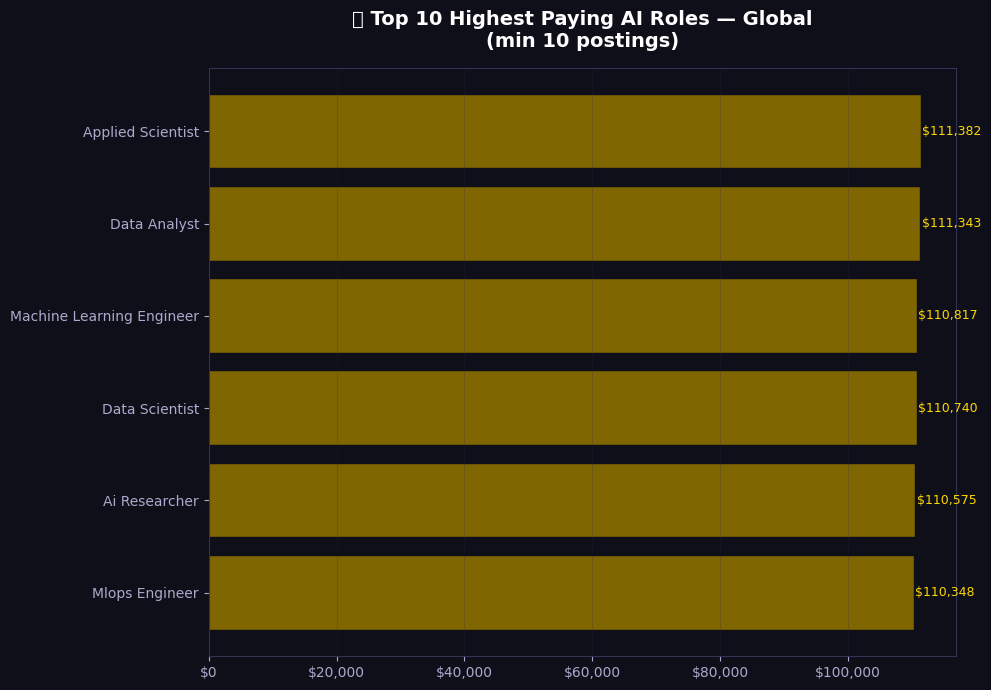

In [ ]:
# @title
# C9: Top 10 Highest Paying AI Roles (min 10 postings)
top_pay = (ai_jobs.groupby('job_title')['salary_avg']
           .agg(['mean', 'count'])
           .reset_index()
           .query('count >= 10')
           .sort_values('mean', ascending=False)
           .head(10)
           .round(0))
top_pay.columns = ['role', 'avg_salary', 'count']
top_pay['role'] = top_pay['role'].str.title()

fig, ax = plt.subplots(figsize=(10, 7))
colors = [GOLD if i < 3 else '#806600' for i in range(10)]

bars = ax.barh(top_pay['role'][::-1],
               top_pay['avg_salary'][::-1],
               color=colors[::-1], edgecolor='#0F0F1A', linewidth=0.3)

for bar in bars:
    ax.text(bar.get_width() + 200,
            bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}',
            va='center', fontsize=9, color=GOLD)

ax.set_title('💎 Top 10 Highest Paying AI Roles — Global\n(min 10 postings)',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('c9_top_paying_roles.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

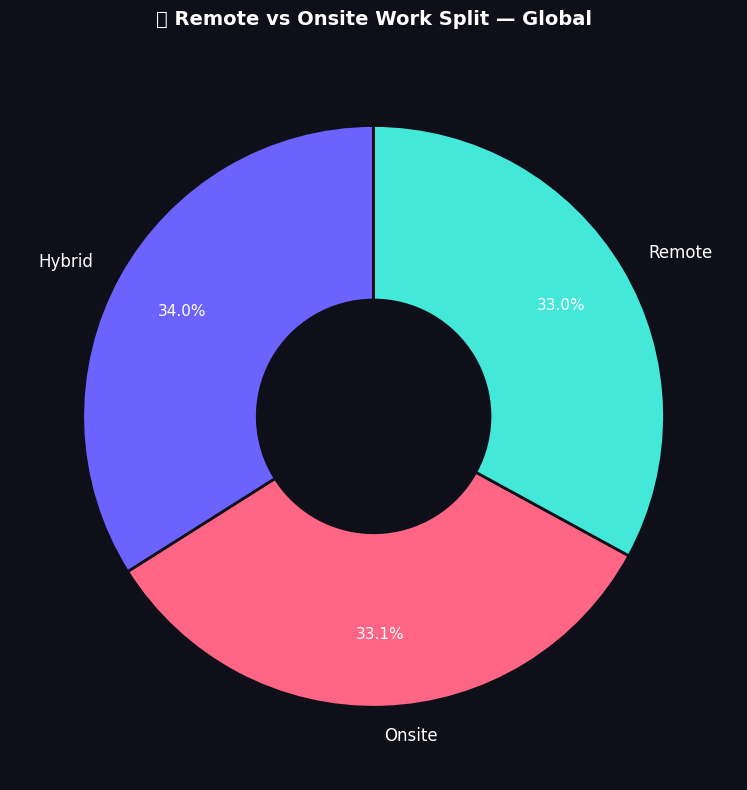

In [ ]:
# @title
# C10: Remote vs Onsite Split — Global
remote = (ai_jobs['remote_type']
          .value_counts()
          .reset_index())
remote.columns = ['type', 'count']
remote['pct'] = (remote['count'] / total_jobs * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 8))
colors = [ACCENT, ACCENT2, ACCENT3, GOLD]

wedges, texts, autotexts = ax.pie(
    remote['count'],
    labels=remote['type'],
    colors=colors[:len(remote)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.6, edgecolor='#0F0F1A', linewidth=2),
    pctdistance=0.75
)
for text in texts:
    text.set_color('white')
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

ax.set_title('🏠 Remote vs Onsite Work Split — Global',
             fontsize=14, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.savefig('c10_remote_split.png', dpi=150,
            bbox_inches='tight', facecolor='#0F0F1A')
plt.show()

# **5. Share**

In [ ]:
# @title
# ============================================================================
# SHARE PHASE — KEY FINDINGS
# ============================================================================

import pandas as pd

findings = {
    "Who hires most?": "UK leads slightly; Germany ~16.7% mid-level share. Hiring is global.",
    "How is the market growing?": "Stable over time — no spikes or drops, globally or in Germany.",
    "What skills are demanded?": "Python, SQL, and cloud (AWS/GCP/Azure) dominate.",
    "What skill types dominate?": "ML, Cloud, and Programming — the three core categories.",
    "What do beginners need?": "SQL, TensorFlow, NLP, cloud basics — even at entry level.",
    "What does Germany want?": "Mirrors global demand, no major local outliers.",
    "What roles exist?": "Data Scientist, ML Engineer, MLOps Engineer, Data Analyst.",
    "What does experience pay?": "Salary rises consistently with experience; Germany near global average.",
    "What roles pay most?": "ML Engineer, Applied Scientist, senior data roles.",
    "How is work structured?": "Split across remote/onsite/hybrid — no dominant mode."
}

df = pd.DataFrame(findings.items(), columns=["Question", "Answer"])
df

,Question,Answer
0,Who hires most?,UK leads slightly; Germany ~16.7% mid-level sh...
1,How is the market growing?,"Stable over time — no spikes or drops, globall..."
2,What skills are demanded?,"Python, SQL, and cloud (AWS/GCP/Azure) dominate."
3,What skill types dominate?,"ML, Cloud, and Programming — the three core ca..."
4,What do beginners need?,"SQL, TensorFlow, NLP, cloud basics — even at e..."
5,What does Germany want?,"Mirrors global demand, no major local outliers."
6,What roles exist?,"Data Scientist, ML Engineer, MLOps Engineer, D..."
7,What does experience pay?,Salary rises consistently with experience; Ger...
8,What roles pay most?,"ML Engineer, Applied Scientist, senior data ro..."
9,How is work structured?,Split across remote/onsite/hybrid — no dominan...


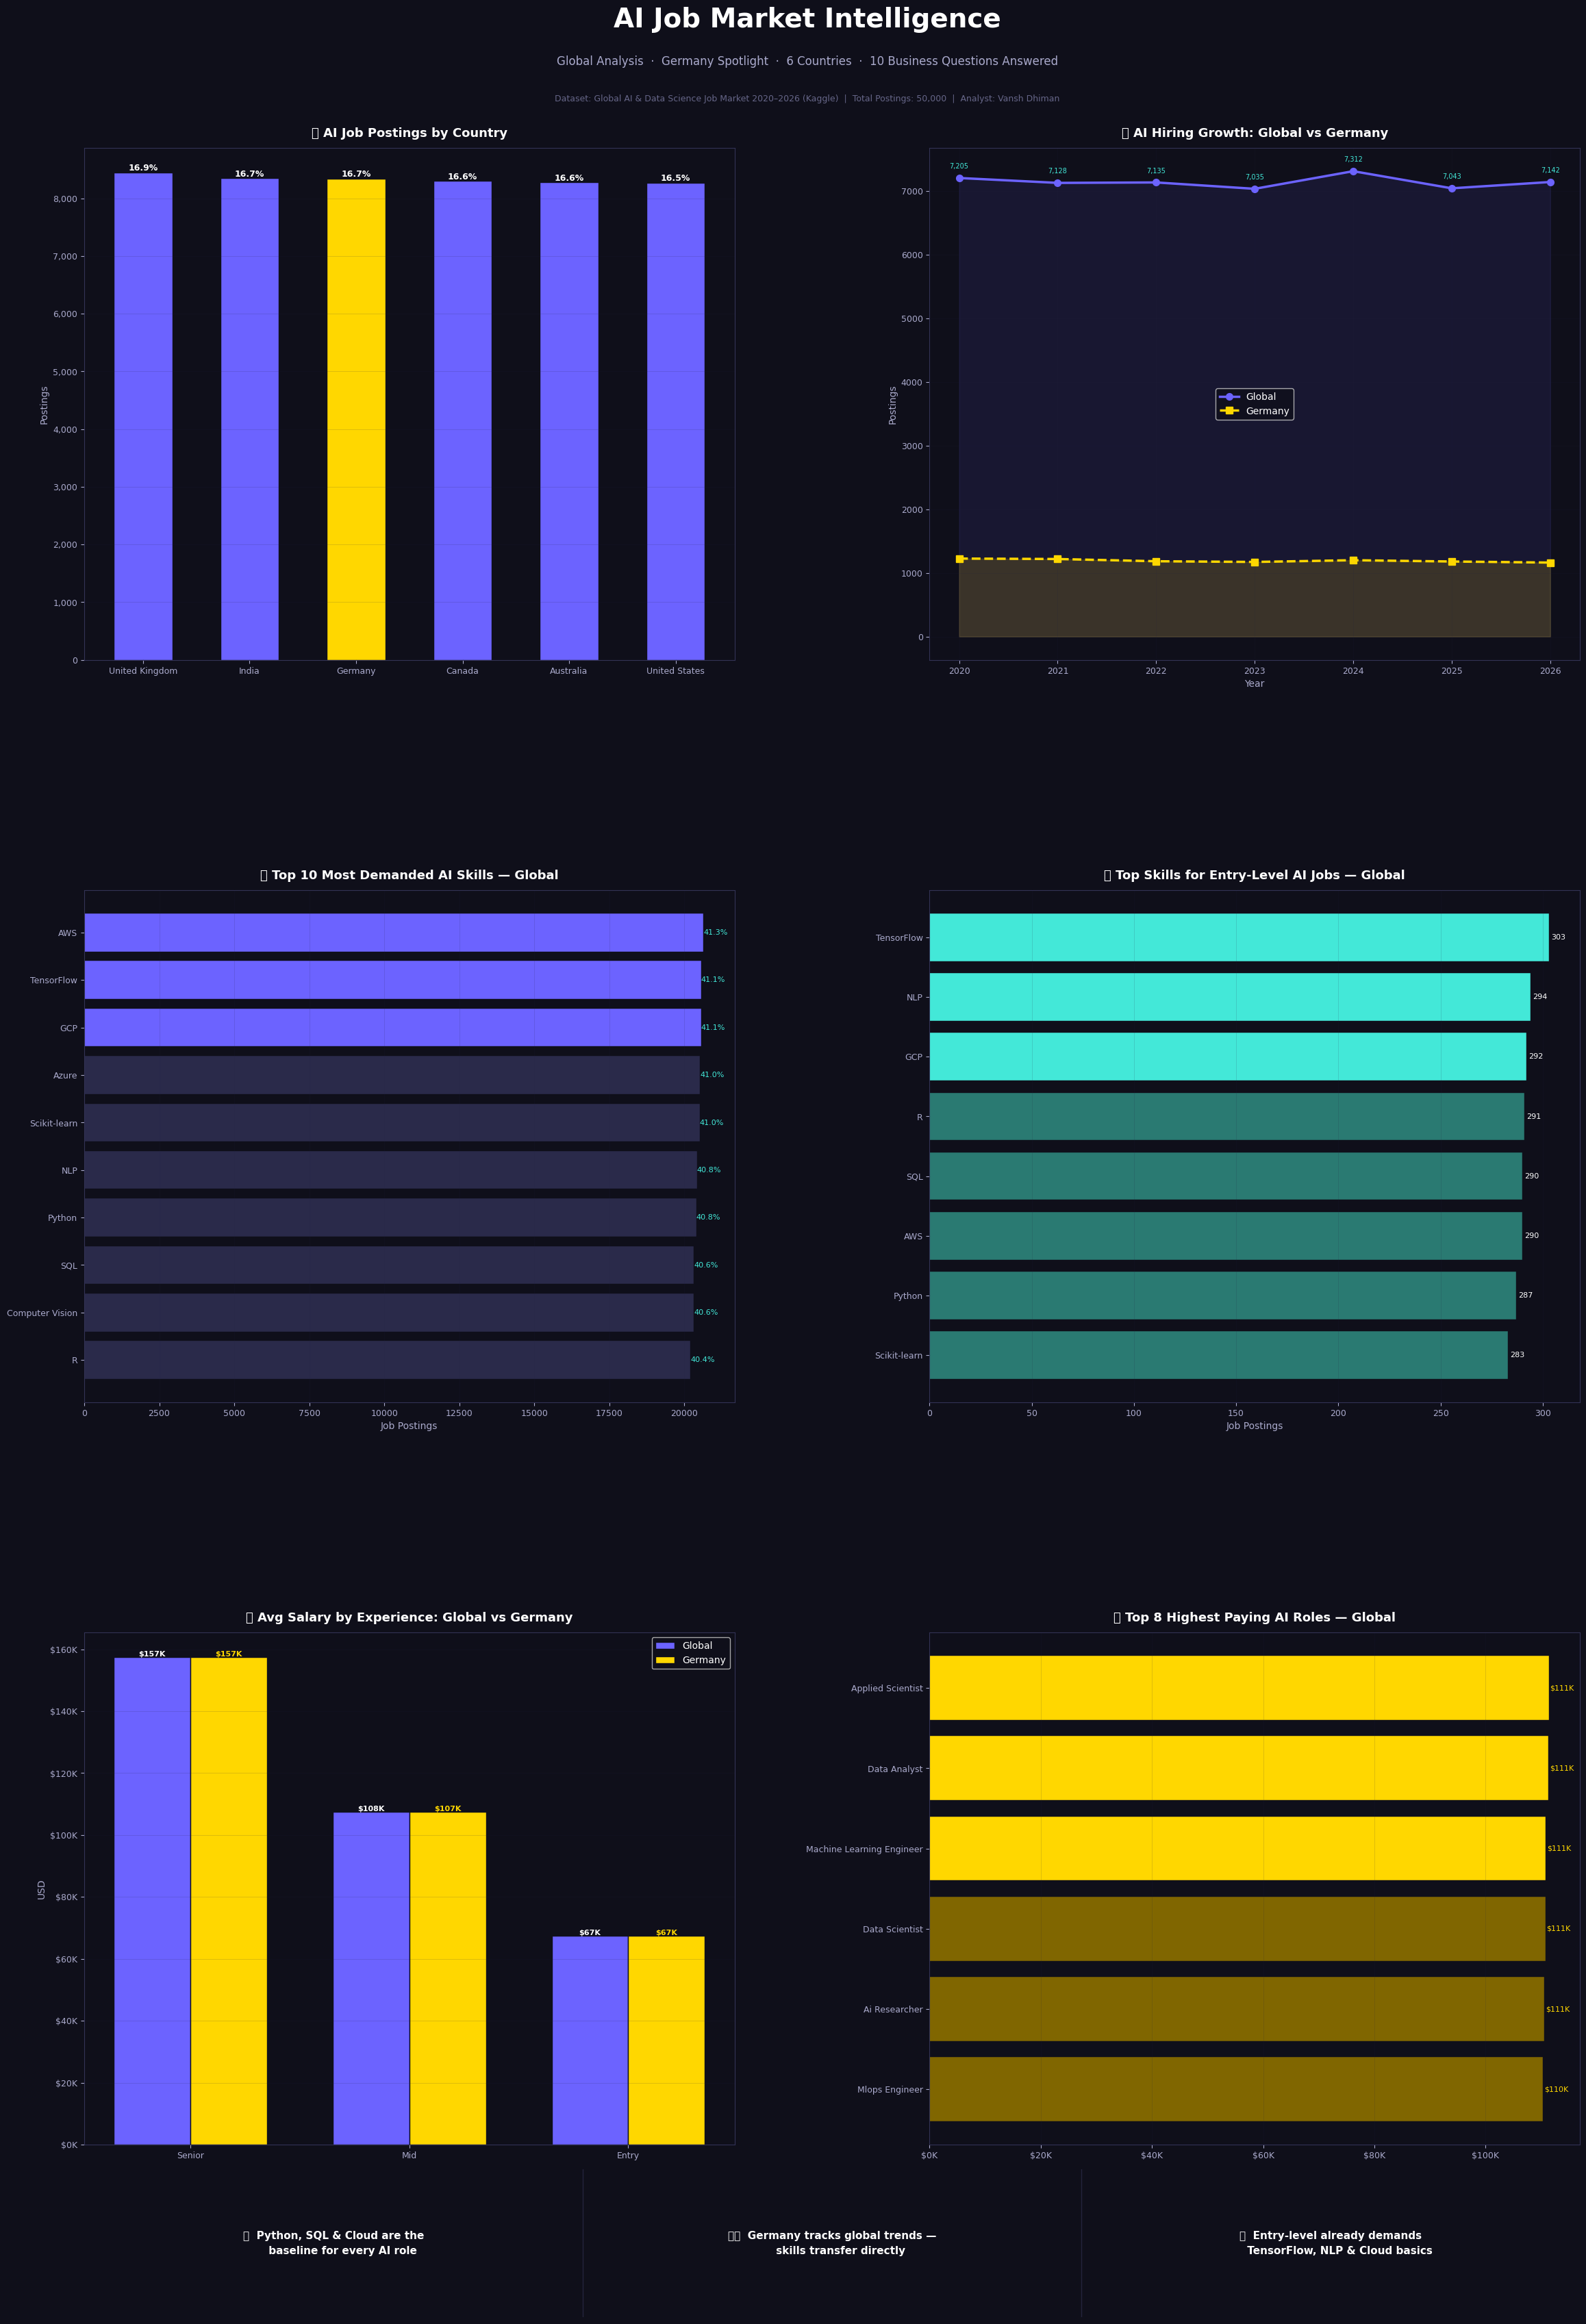


✅ SHARE PHASE COMPLETE
   Poster exported → share_summary_poster.png
   Next → Act Phase: Recommendations


In [ ]:
# @title
# ============================================================================
# SHARE PHASE — CELL 2: SUMMARY POSTER (FIXED)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── RECOMPUTE ALL DATA ────────────────────────────────────────────────────────

# C1: Jobs by country
jobs_by_country = (ai_jobs['country_clean']
                   .str.title()
                   .value_counts()
                   .reset_index())
jobs_by_country.columns = ['country', 'count']
jobs_by_country['pct'] = (
    jobs_by_country['count'] / total_jobs * 100).round(1)

# C2: Hiring trend
jobs_by_year = (ai_jobs.groupby('posted_year')
                .size().reset_index(name='global_count'))
germany_by_year = (germany_jobs.groupby('posted_year')
                   .size().reset_index(name='germany_count'))
trend = jobs_by_year.merge(germany_by_year, on='posted_year', how='left')

# C3: Top 10 skills
top_skills = (skills_demand
              .groupby('skill')['job_id']
              .nunique()
              .sort_values(ascending=False)
              .head(10)
              .reset_index())
top_skills.columns = ['skill', 'count']
top_skills['pct'] = (top_skills['count'] / total_jobs * 100).round(1)

# C5: Entry-level skills top 8
entry_ids = set(ai_jobs[
    ai_jobs['experience_level'].str.lower() == 'entry']['job_id'])
entry_skills_poster = (
    skills_demand[skills_demand['job_id'].isin(entry_ids)]
    .groupby('skill')['job_id']
    .nunique()
    .sort_values(ascending=False)
    .head(8)
    .reset_index())
entry_skills_poster.columns = ['skill', 'count']

# C8: Salary by experience
sal_global = (ai_jobs.groupby('experience_level')['salary_avg']
              .mean().round(0).reset_index())
sal_global.columns = ['level', 'global_avg']
sal_de = (germany_jobs.groupby('experience_level')['salary_avg']
          .mean().round(0).reset_index())
sal_de.columns = ['level', 'germany_avg']
sal = sal_global.merge(sal_de, on='level', how='left').sort_values(
    'global_avg', ascending=False)

# C9: Top 8 paying roles
top_pay = (ai_jobs.groupby('job_title')['salary_avg']
           .agg(['mean', 'count'])
           .reset_index()
           .query('count >= 10')
           .sort_values('mean', ascending=False)
           .head(8)
           .round(0))
top_pay.columns = ['role', 'avg_salary', 'count']
top_pay['role'] = top_pay['role'].str.title()

# ── COLORS ────────────────────────────────────────────────────────────────────
ACCENT  = '#6C63FF'
ACCENT2 = '#FF6584'
ACCENT3 = '#43E8D8'
GOLD    = '#FFD700'
GRAY    = '#2A2A4A'
BG      = '#0F0F1A'

# ── POSTER LAYOUT ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(24, 36))
fig.patch.set_facecolor(BG)

gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    hspace=0.45,
    wspace=0.3,
    top=0.91,
    bottom=0.10,
    left=0.06,
    right=0.97
)

axes = [
    fig.add_subplot(gs[0, 0]),  # C1 - jobs by country
    fig.add_subplot(gs[0, 1]),  # C2 - trend
    fig.add_subplot(gs[1, 0]),  # C3 - top skills
    fig.add_subplot(gs[1, 1]),  # C5 - entry skills
    fig.add_subplot(gs[2, 0]),  # C8 - salary
    fig.add_subplot(gs[2, 1]),  # C9 - top paying roles
]

for ax in axes:
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333355')

# ── PANEL 1: Jobs by Country ──────────────────────────────────────────────────
ax = axes[0]
bar_colors = [GOLD if c == 'Germany' else ACCENT
              for c in jobs_by_country['country']]
bars = ax.bar(jobs_by_country['country'],
              jobs_by_country['count'],
              color=bar_colors, edgecolor=BG, width=0.55)
for bar, pct in zip(bars, jobs_by_country['pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{pct}%', ha='center', fontsize=9,
            color='white', fontweight='bold')
ax.set_title('🌍 AI Job Postings by Country',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_ylabel('Postings', fontsize=10, color='#AAAACC')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(colors='#AAAACC', labelsize=9)
ax.grid(axis='y', alpha=0.2)

# ── PANEL 2: Hiring Trend ─────────────────────────────────────────────────────
ax = axes[1]
ax.plot(trend['posted_year'], trend['global_count'],
        color=ACCENT, linewidth=2.5, marker='o',
        markersize=7, label='Global')
ax.plot(trend['posted_year'], trend['germany_count'],
        color=GOLD, linewidth=2.5, marker='s',
        markersize=7, label='Germany', linestyle='--')
ax.fill_between(trend['posted_year'],
                trend['global_count'], alpha=0.1, color=ACCENT)
ax.fill_between(trend['posted_year'],
                trend['germany_count'], alpha=0.15, color=GOLD)
for x, y in zip(trend['posted_year'], trend['global_count']):
    ax.annotate(f'{y:,}', (x, y),
                textcoords='offset points',
                xytext=(0, 10), ha='center',
                fontsize=7, color=ACCENT3)
ax.set_title('📈 AI Hiring Growth: Global vs Germany',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Year', fontsize=10, color='#AAAACC')
ax.set_ylabel('Postings', fontsize=10, color='#AAAACC')
ax.legend(fontsize=10, facecolor=BG, labelcolor='white')
ax.tick_params(colors='#AAAACC', labelsize=9)
ax.grid(alpha=0.2)

# ── PANEL 3: Top 10 Skills ────────────────────────────────────────────────────
ax = axes[2]
colors = [ACCENT if i < 3 else GRAY for i in range(len(top_skills))]
bars = ax.barh(top_skills['skill'][::-1],
               top_skills['count'][::-1],
               color=colors[::-1], edgecolor=BG, linewidth=0.3)
for bar, pct in zip(bars, top_skills['pct'][::-1]):
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=8, color=ACCENT3)
ax.set_title('🛠️ Top 10 Most Demanded AI Skills — Global',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Job Postings', fontsize=10, color='#AAAACC')
ax.tick_params(colors='#AAAACC', labelsize=9)
ax.grid(axis='x', alpha=0.2)

# ── PANEL 4: Entry-Level Skills ───────────────────────────────────────────────
ax = axes[3]
colors = [ACCENT3 if i < 3 else '#2A7A72'
          for i in range(len(entry_skills_poster))]
bars = ax.barh(entry_skills_poster['skill'][::-1],
               entry_skills_poster['count'][::-1],
               color=colors[::-1], edgecolor=BG, linewidth=0.3)
for bar in bars:
    ax.text(bar.get_width() + 1,
            bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}',
            va='center', fontsize=8, color='white')
ax.set_title('🟢 Top Skills for Entry-Level AI Jobs — Global',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Job Postings', fontsize=10, color='#AAAACC')
ax.tick_params(colors='#AAAACC', labelsize=9)
ax.grid(axis='x', alpha=0.2)

# ── PANEL 5: Salary by Experience ────────────────────────────────────────────
ax = axes[4]
x = np.arange(len(sal))
w = 0.35
bars1 = ax.bar(x - w/2, sal['global_avg'], w,
               label='Global', color=ACCENT, edgecolor=BG)
bars2 = ax.bar(x + w/2, sal['germany_avg'], w,
               label='Germany', color=GOLD, edgecolor=BG)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f'${bar.get_height()/1000:.0f}K',
            ha='center', fontsize=8,
            color='white', fontweight='bold')
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 300,
                f'${bar.get_height()/1000:.0f}K',
                ha='center', fontsize=8,
                color=GOLD, fontweight='bold')
ax.set_title('💰 Avg Salary by Experience: Global vs Germany',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(sal['level'], fontsize=9, color='#AAAACC')
ax.set_ylabel('USD', fontsize=10, color='#AAAACC')
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=10, facecolor=BG, labelcolor='white')
ax.tick_params(colors='#AAAACC', labelsize=9)
ax.grid(axis='y', alpha=0.2)

# ── PANEL 6: Top Paying Roles ─────────────────────────────────────────────────
ax = axes[5]
colors = [GOLD if i < 3 else '#806600' for i in range(len(top_pay))]
bars = ax.barh(top_pay['role'][::-1],
               top_pay['avg_salary'][::-1],
               color=colors[::-1], edgecolor=BG, linewidth=0.3)
for bar in bars:
    ax.text(bar.get_width() + 200,
            bar.get_y() + bar.get_height()/2,
            f'${bar.get_width()/1000:.0f}K',
            va='center', fontsize=8, color=GOLD)
ax.set_title('💎 Top 8 Highest Paying AI Roles — Global',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.tick_params(colors='#AAAACC', labelsize=9)
ax.grid(axis='x', alpha=0.2)

# ── FOOTER: 3 KEY FINDINGS ────────────────────────────────────────────────────
footer_ax = fig.add_axes([0.06, 0.03, 0.91, 0.06])
footer_ax.set_facecolor('#1A1A2E')
footer_ax.set_xlim(0, 3)
footer_ax.set_ylim(0, 1)
footer_ax.axis('off')

key_findings = [
    "🔑  Python, SQL & Cloud are the\n     baseline for every AI role",
    "🇩🇪  Germany tracks global trends —\n     skills transfer directly",
    "💡  Entry-level already demands\n     TensorFlow, NLP & Cloud basics",
]

for i, text in enumerate(key_findings):
    footer_ax.text(
        i + 0.5, 0.5, text,
        ha='center', va='center',
        fontsize=11, color='white',
        fontweight='bold',
        linespacing=1.6
    )
    if i < 2:
        footer_ax.axvline(x=i + 1, color='#333355',
                          linewidth=1, alpha=0.6)

# ── MAIN TITLE ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.962,
         'AI Job Market Intelligence',
         ha='center', va='center',
         fontsize=28, fontweight='bold', color='white')
fig.text(0.5, 0.945,
         'Global Analysis  ·  Germany Spotlight  ·  6 Countries  ·  10 Business Questions Answered',
         ha='center', va='center',
         fontsize=12, color='#AAAACC')
fig.text(0.5, 0.930,
         f'Dataset: Global AI & Data Science Job Market 2020–2026 (Kaggle)  |  '
         f'Total Postings: {total_jobs:,}  |  Analyst: Vansh Dhiman',
         ha='center', va='center',
         fontsize=9, color='#666688')

# ── EXPORT ────────────────────────────────────────────────────────────────────
plt.savefig('share_summary_poster.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

print("\n✅ SHARE PHASE COMPLETE")
print("   Poster exported → share_summary_poster.png")
print("   Next → Act Phase: Recommendations")

# **6. Act**

In [ ]:
# @title
# ============================================================================
# ACT PHASE — RECOMMENDATIONS & LIMITATIONS
# ============================================================================

recommendations = [
    {
        "rec": "Close the skill-readiness gap",
        "detail": "Entry-level roles already require production tools (SQL, TensorFlow, NLP, cloud) — not just theory.",
        "supporting_finding": "F5"
    },
    {
        "rec": "Don't restrict job search by geography",
        "detail": "Germany mirrors global skill demand — apply cross-border and remote rather than limiting to one market.",
        "supporting_finding": "F1, F6, F10"
    },
    {
        "rec": "Specialize early",
        "detail": "Applied roles (ML Engineer, Applied Scientist) consistently outpay research-track roles.",
        "supporting_finding": "F7, F9"
    },
]

print("=" * 70)
print("  ACT PHASE — TOP 3 RECOMMENDATIONS")
print("=" * 70)

for i, r in enumerate(recommendations, 1):
    print(f"\n{'─' * 70}")
    print(f"  #{i}  {r['rec']}")
    print(f"{'─' * 70}")
    print(f"  → {r['detail']}")
    print(f"  Supporting finding(s): {r['supporting_finding']}")

print(f"\n{'=' * 70}")
print("  LIMITATIONS")
print("=" * 70)
limitations = [
    "Dataset covers only 6 countries — Germany is the only EU data point, not a Europe-wide sample.",
    "Salary in USD, no PPP adjustment — doesn't reflect local cost-of-living.",
    "'AI job' labels come from the dataset's own classification — may overlap with general data roles.",
    "No job-description text — findings are structural (titles, skills, salary), not contextual.",
]
for l in limitations:
    print(f"  • {l}")

print(f"\n{'=' * 70}")
print("  PROJECT COMPLETE — Ask → Prepare → Process → Analyze → Share → Act")
print("=" * 70)

  ACT PHASE — TOP 3 RECOMMENDATIONS

──────────────────────────────────────────────────────────────────────
  #1  Close the skill-readiness gap
──────────────────────────────────────────────────────────────────────
  → Entry-level roles already require production tools (SQL, TensorFlow, NLP, cloud) — not just theory.
  Supporting finding(s): F5

──────────────────────────────────────────────────────────────────────
  #2  Don't restrict job search by geography
──────────────────────────────────────────────────────────────────────
  → Germany mirrors global skill demand — apply cross-border and remote rather than limiting to one market.
  Supporting finding(s): F1, F6, F10

──────────────────────────────────────────────────────────────────────
  #3  Specialize early
──────────────────────────────────────────────────────────────────────
  → Applied roles (ML Engineer, Applied Scientist) consistently outpay research-track roles.
  Supporting finding(s): F7, F9

  LIMITATIONS
  • Dataset co